# Antibiotic Resistance Prediction

## Objective

This project aims to predict whether a bacterial isolate is resistant to antibiotics using machine learning models applied to microbiological data.

## Why this matters

Antimicrobial resistance is a major global health challenge. Predictive models can support clinical decision-making and antimicrobial stewardship by identifying high-risk resistant infections.

In [28]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix
)

In [29]:
df = pd.read_csv("Bacteria_dataset_Multiresictance.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10710, 27)


,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,...,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,Notes
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,S,S,R,S,S,S,5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,S,S,S,S,S,S,08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,S,R,R,S,S,S,01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,...,R,S,S,S,S,S,S,S,error,NADA


In [30]:
df.columns

Index(['ID', 'Name', 'Email', 'Address', 'age/gender', 'Souches', 'Diabetes',
       'Hypertension', 'Hospital_before', 'Infection_Freq', 'AMX/AMP', 'AMC',
       'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 'Acide nalidixique', 'ofx',
       'CIP', 'C', 'Co-trimoxazole', 'Furanes', 'colistine', 'Collection_Date',
       'Notes'],
      dtype='object')

In [31]:
# Remove identifiers and free-text columns
df.drop(columns=[
    "ID",
    "Name",
    "Email",
    "Address",
    "Notes"
], inplace=True)

print("Shape after dropping identifiers:", df.shape)

Shape after dropping identifiers: (10710, 22)


In [32]:
df.columns.tolist()

['age/gender',
 'Souches',
 'Diabetes',
 'Hypertension',
 'Hospital_before',
 'Infection_Freq',
 'AMX/AMP',
 'AMC',
 'CZ',
 'FOX',
 'CTX/CRO',
 'IPM',
 'GEN',
 'AN',
 'Acide nalidixique',
 'ofx',
 'CIP',
 'C',
 'Co-trimoxazole',
 'Furanes',
 'colistine',
 'Collection_Date']

In [33]:
antibiotic_cols = [
    'AMX/AMP',
    'AMC',
    'CZ',
    'FOX',
    'CTX/CRO',
    'IPM',
    'GEN',
    'AN',
    'Acide nalidixique',
    'ofx',
    'CIP',
    'C',
    'Co-trimoxazole',
    'Furanes',
    'colistine'
]

# Count resistant antibiotics
df["num_resistant"] = df[antibiotic_cols].apply(
    lambda row: sum(row == "R"),
    axis=1
)

df["num_resistant"].head()

0    7
1    3
2    4
3    0
4    6
Name: num_resistant, dtype: int64

In [34]:
# Create multi-drug resistance outcome
df["MDR"] = df["num_resistant"].apply(
    lambda x: 1 if x >= 3 else 0
)

# Check distribution
df["MDR"].value_counts()

MDR
1    7786
0    2924
Name: count, dtype: int64

In [35]:
X = df.drop("MDR", axis=1)
y = df["MDR"]

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

X shape: (10710, 23)
y distribution:
MDR
1    7786
0    2924
Name: count, dtype: int64


In [36]:
# Split age and gender into two separate columns

df["Age"] = df["age/gender"].str.split("/").str[0]
df["Gender"] = df["age/gender"].str.split("/").str[1]

# Convert Age to numeric
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Drop original combined column
df.drop(columns=["age/gender"], inplace=True)

df[["Age", "Gender"]].head()

,Age,Gender
0,37.0,F
1,29.0,F
2,77.0,F
3,NaN,NaN
4,13.0,F


In [37]:
# Fill missing Age with median age
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Gender with most common value
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [38]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])

In [39]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 13336


In [40]:
# Fill numeric columns with median
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill object columns with 'Missing'
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("Missing")

# Check again
print("Total missing values after cleanup:", df.isnull().sum().sum())

Total missing values after cleanup: 0


In [41]:
# Encode all remaining categorical columns

label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [42]:
df.dtypes

Souches                int64
Diabetes               int64
Hypertension           int64
Hospital_before        int64
Infection_Freq         int64
AMX/AMP                int64
AMC                    int64
CZ                     int64
FOX                    int64
CTX/CRO                int64
IPM                    int64
GEN                    int64
AN                     int64
Acide nalidixique      int64
ofx                    int64
CIP                    int64
C                      int64
Co-trimoxazole         int64
Furanes                int64
colistine              int64
Collection_Date        int64
num_resistant          int64
MDR                    int64
Age                  float64
Gender                 int64
dtype: object

In [43]:
# Convert date to useful numeric feature

df["Collection_Date"] = pd.to_datetime(
    df["Collection_Date"],
    errors="coerce"
)

df["Year"] = df["Collection_Date"].dt.year
df["Month"] = df["Collection_Date"].dt.month

df.drop(columns=["Collection_Date"], inplace=True)

In [44]:
print(df.columns)

Index(['Souches', 'Diabetes', 'Hypertension', 'Hospital_before',
       'Infection_Freq', 'AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM',
       'GEN', 'AN', 'Acide nalidixique', 'ofx', 'CIP', 'C', 'Co-trimoxazole',
       'Furanes', 'colistine', 'num_resistant', 'MDR', 'Age', 'Gender', 'Year',
       'Month'],
      dtype='object')


In [45]:
df.drop(columns=["num_resistant"], inplace=True, errors="ignore")

In [46]:
X = df.drop("MDR", axis=1)
y = df["MDR"]

In [47]:
print(X.select_dtypes(include="object").columns)

Index([], dtype='object')


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_preds))

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, log_probs))

print("\nClassification Report:\n")
print(classification_report(y_test, log_preds))

Logistic Regression Accuracy: 0.7945845004668534
Logistic Regression ROC-AUC: 0.8648343022138782

Classification Report:

              precision    recall  f1-score   support

           0       0.59      0.79      0.68       585
           1       0.91      0.80      0.85      1557

    accuracy                           0.79      2142
   macro avg       0.75      0.79      0.76      2142
weighted avg       0.82      0.79      0.80      2142



C:\Users\astra\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_preds))

print("XGBoost ROC-AUC:",
      roc_auc_score(y_test, xgb_probs))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds))

XGBoost Accuracy: 0.9981325863678805
XGBoost ROC-AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       585
           1       1.00      1.00      1.00      1557

    accuracy                           1.00      2142
   macro avg       1.00      1.00      1.00      2142
weighted avg       1.00      1.00      1.00      2142



In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_preds))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_probs))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.9864612511671336
Random Forest ROC-AUC: 0.9993758542891491

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       585
           1       0.99      0.99      0.99      1557

    accuracy                           0.99      2142
   macro avg       0.98      0.98      0.98      2142
weighted avg       0.99      0.99      0.99      2142



In [52]:
results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
}

comparison_table = pd.DataFrame(results)

comparison_table

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.794585,0.864834
1,Random Forest,0.986461,0.999376
2,XGBoost,0.998133,1.000000


In [53]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,Co-trimoxazole,0.159062
5,AMX/AMP,0.092051
6,AMC,0.083770
7,CZ,0.076316
9,CTX/CRO,0.070356
13,Acide nalidixique,0.069946
12,AN,0.068875
8,FOX,0.060125
10,IPM,0.059663
15,CIP,0.058448


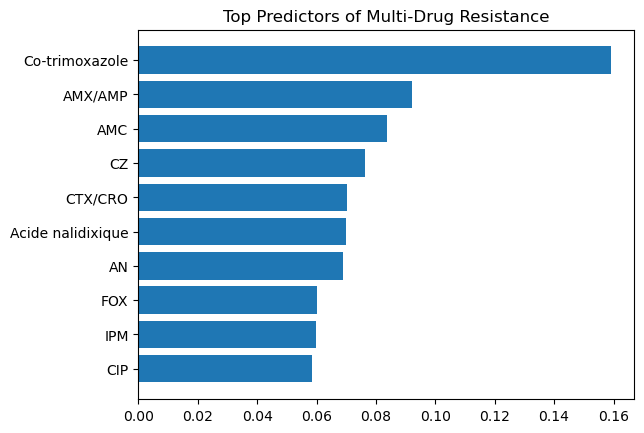

In [54]:
plt.figure()

plt.barh(
    feature_importance["Feature"].head(10),
    feature_importance["Importance"].head(10)
)

plt.title("Top Predictors of Multi-Drug Resistance")

plt.gca().invert_yaxis()

plt.show()